In [1]:
import tarfile
import zipfile
import io
import os
import time
import math
import pickle
import itertools as itr
import collections as coll
import functools as ft
import regex as re
import chardet
from tqdm.auto import tqdm
from pytictoc import TicToc
import json

import pandas as pd
import numpy as np

import gcsfs
fs = gcsfs.GCSFileSystem()

from google.cloud import storage
from google.cloud.exceptions import ClientError

PROJECT_ID = "arxiv-development"
PRD_PROJECT = 'arxiv-production'
PRD_BUCKET_LOC = 'arxiv-production-data' 

from pylatexenc.latexwalker import LatexWalker, LatexEnvironmentNode, LatexGroupNode, LatexMacroNode, LatexCharsNode
from pylatexenc.latex2text import LatexNodes2Text


In [2]:
os.chdir("/home/jupyter/metadata-vertexai/")  # this needs to be the folder where notebook lives
import importlib
import phase_one_json as phase_one


In [3]:
#ror_rebuilt = phase_one.rorFinder(RECREATE_INDEX=True)

In [4]:
from IPython.core.interactiveshell import InteractiveShell
# pretty print all cell's output and not just the last one
InteractiveShell.ast_node_interactivity = "all"

In [5]:
def safe_divide(num, denom):
    return num / denom if denom != 0 else 0.0

Note that id lists were prepared previously from the DB, using:  

```
select concat(paper_id,"v",version) as arx_id from arXiv_metadata
where paper_id LIKE "23%"
and is_withdrawn != 1
and is_current = 1;
```

In [6]:
ror_gspath = 'gs://institutional-extract-scratch/reference/v1.63-2025-04-03-ror-data_schema_v2.json'
fs = gcsfs.GCSFileSystem()
with fs.open(ror_gspath, "r", encoding="utf-8") as f:
    ror_data = json.load(f)
ror_dict = {x['id'].rsplit('/')[-1]: x for x in ror_data}

In [15]:
#ror_dict['043mz5j54']
ror_dict['057qpr032']

{'admin': {'created': {'date': '2018-11-14', 'schema_version': '1.0'},
  'last_modified': {'date': '2025-02-26', 'schema_version': '2.1'}},
 'domains': [],
 'established': 1896,
 'external_ids': [{'all': ['501100006251'],
   'preferred': None,
   'type': 'fundref'},
  {'all': ['grid.412041.2'], 'preferred': 'grid.412041.2', 'type': 'grid'},
  {'all': ['0000 0001 2106 639X'], 'preferred': None, 'type': 'isni'},
  {'all': ['Q13344'], 'preferred': None, 'type': 'wikidata'}],
 'id': 'https://ror.org/057qpr032',
 'links': [{'type': 'website', 'value': 'http://www.u-bordeaux.com/'},
  {'type': 'wikipedia',
   'value': 'http://en.wikipedia.org/wiki/University_of_Bordeaux'}],
 'locations': [{'geonames_details': {'continent_code': 'EU',
    'continent_name': 'Europe',
    'country_code': 'FR',
    'country_name': 'France',
    'country_subdivision_code': 'NAQ',
    'country_subdivision_name': 'Nouvelle-Aquitaine',
    'lat': 44.84044,
    'lng': -0.5805,
    'name': 'Bordeaux'},
   'geonames_id

In [8]:
def get_children_for_ror(target_id):
    res_list = []
    rels = ror_dict[target_id].get('relationships',[])
    for rel in rels:
        rel_type = rel.get('type','')
        if rel_type not in ['child', 'predecessor']:
            continue
        child_id = rel.get('id','').rsplit('/')[-1]
        if child_id:
            res_list.append(child_id)
    return res_list


In [9]:
get_ror = phase_one.ROR_FINDER.get_ror

In [10]:
def get_ror_details(ror):
    ror_id = ror
    if not ror_id.startswith('https'):
        ror_id = f"https://ror.org/{ror}"
    res = docs.get(ror_id, {})
    return res

In [11]:
def ror_best_match(inst_dict):
    ror_best = get_ror(**inst_dict)
    return get_ror_details(ror_best)
    
    

In [12]:
def fake_ror(acm_str):
    fake_ror = f"https://ror.org/arx{np.base_repr(int(acm_str), 36).zfill(6)[-6:].lower()}"
    return fake_ror

In [13]:
fake_ror("60104353")

'https://ror.org/arx0zs8td'

In [17]:
get_ror_details('057qpr032')

{'ROR ID': 'https://ror.org/057qpr032',
 'name': 'Bordeaux Segalen University',
 'acronym': '',
 'url': 'http://www.univ-bordeauxsegalen.fr',
 'loc_name': 'Bordeaux',
 'ctry_name': 'France'}

In [14]:
## Manual corrections:
need_fake_ror = [
    "60104353",    
]

for org_id in need_fake_ror:
    ror_map_df.loc[org_id, "ROR ID"] = fake_ror(org_id)
    print(f"{org_id}: {fake_ror(org_id)}")

    
known_remap = {
    '60000027': "https://ror.org/02rqhpa98"
}
for org_id, ror in known_remap.items():
    ror_map_df.loc[org_id, "ROR ID"] = ror

NameError: name 'ror_map_df' is not defined

## also include the org name and country from ROR


In [16]:
ror_wd_map = phase_one.ROR_FINDER.withdrawn_map if phase_one.ROR_FINDER.withdrawn_map else phase_one.ROR_FINDER.build_withdrawn_map()


ror_gspath = 'gs://institutional-extract-scratch/reference/v1.63-2025-04-03-ror-data_schema_v2.json'

replace_country = {
    'Russia': 'Russian Federation',
    'Türkiye': 'Turkey',
    'The Netherlands': 'Netherlands',
    'Vietnam': 'Viet Nam',
    'Czechia': 'Czech Republic',
} 

fs = gcsfs.GCSFileSystem()
with fs.open(ror_gspath, "r", encoding="utf-8") as f:
    ror_data = json.load(f)

#Parse into training docs
docs = {}
#docs = load_special_cases_ror()
for i,entry in tqdm(enumerate(ror_data)):
    ror_id = entry.get("id", "")
    if not ror_id:
        continue
    # Check if withdrawn and link to active successor
    # We dont want to do this in this context
    # ror_id = ror_wd_map.get(ror_id, ror_id)

    locs = entry.get('locations',[])
    loc_name = ""
    ctry_name = ""
    try:
        loc_name = f"{locs[0]['geonames_details']['name']}"
    except KeyError:
        pass
    try:
        ctry_name = f"{locs[0]['geonames_details']['country_name']}"
        ctry_name = replace_country.get(ctry_name, ctry_name)
    except KeyError:
        pass

    link = ''
    for link_obj in entry.get('links', []):
        if link_obj['type'] == 'website':
            link = link_obj['value'] 
            break

    full_name = ""
    acronym = ""
    for name_info in entry.get("names", {}):
        name = name_info.get("value", "")
        if 'acronym' in name_info.get("types", []):
            acronym = name
        if name_info.get("lang") == "en":
            full_name = name
        if not full_name and 'ror_display' in name_info.get("types", []):
            full_name = name
    docs[ror_id] = {
        'ROR ID': ror_id,
        'name': full_name,
        'acronym': acronym,
        'url': link,
        'loc_name': loc_name,
        'ctry_name': ctry_name,
    }

  0%|          | 0/2091 [00:00<?, ?it/s]

  0%|          | 0/44 [00:00<?, ?it/s]

0it [00:00, ?it/s]

In [20]:
ror_id = "057qpr032"
ror_wd_map.get(ror_id, ror_id)
ror_dict[ror_id].get("names")
get_ror_details(ror_id)

'057qpr032'

[{'lang': 'eu', 'types': ['label'], 'value': 'Bordeleko Unibertsitatea'},
 {'lang': 'en', 'types': ['label'], 'value': 'University of Bordeaux'},
 {'lang': 'fr',
  'types': ['label', 'ror_display'],
  'value': 'Université de Bordeaux'}]

{'ROR ID': 'https://ror.org/057qpr032',
 'name': 'Bordeaux Segalen University',
 'acronym': '',
 'url': 'http://www.univ-bordeauxsegalen.fr',
 'loc_name': 'Bordeaux',
 'ctry_name': 'France'}

## Load the file with orgs to match to ROR

In [22]:
acm_df = pd.read_csv("acm_dl_parsed.csv")
acm_df.head()

,org_id,name,link,city,region,country
0,60032491,Institute of Construction and Architecture Slo...,NaN,Bratislava,Bratislava Region,Slovakia
1,60069709,General Research Institute for Non-ferrous Met...,NaN,Beijing,NaN,China
2,60007776,Cornell University,https://www.cornell.edu/,Ithaca,NY,United States
3,60020968,Smith Kettlewell Eye Research Institute,http://www.ski.org/,San Francisco,CA,United States
4,60115335,Laboratório de Engenharia Matemática,http://www.lema.isep.ipp.pt,Porto,Porto,Portugal


In [34]:
res_list = []
for row in tqdm(acm_df.itertuples(), total=acm_df.shape[0]):
    res = {'org_id': row.org_id}
    inst_dict = {
        'inst_name': row.name,
        'inst_city': row.city,
        'inst_cntry': row.country,
    }
    res['name_acm'] = row.name
    res['url_acm'] = row.link
    res['city_acm'] = row.city
    res['region_acm'] = row.region
    res['country_acm'] = row.country
    res.update(ror_best_match(inst_dict))
    res_list.append(res)

  0%|          | 0/29322 [00:00<?, ?it/s]

In [35]:
res_df = pd.DataFrame.from_records(res_list)
res_df.head()

,org_id,name_acm,url_acm,city_acm,region_acm,country_acm,ROR ID,name,acronym,url,loc_name,ctry_name
0,60032491,Institute of Construction and Architecture Slo...,NaN,Bratislava,Bratislava Region,Slovakia,https://ror.org/006ghkj05,Institute of Construction and Architecture of ...,,http://www.ustarch.sav.sk,Bratislava,Slovakia
1,60069709,General Research Institute for Non-ferrous Met...,NaN,Beijing,NaN,China,https://ror.org/01g0gmx67,Northwest Institute For Non-Ferrous Metal Rese...,NIN,http://www.c-nin.com/english/,Xi'an,China
2,60007776,Cornell University,https://www.cornell.edu/,Ithaca,NY,United States,https://ror.org/05bnh6r87,Cornell University,CU,https://www.cornell.edu,Ithaca,United States
3,60020968,Smith Kettlewell Eye Research Institute,http://www.ski.org/,San Francisco,CA,United States,https://ror.org/05783y657,Smith-Kettlewell Eye Research Institute,SKERI,http://www.ski.org/,San Francisco,United States
4,60115335,Laboratório de Engenharia Matemática,http://www.lema.isep.ipp.pt,Porto,Porto,Portugal,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
res_df.to_csv("acm_dl_matched.csv", index=False)

In [42]:
res_df.columns

Index(['org_id', 'name_acm', 'url_acm', 'city_acm', 'region_acm',
       'country_acm', 'ROR ID', 'name', 'acronym', 'url', 'loc_name',
       'ctry_name'],
      dtype='object')

## Use Gemini to assess match quality

In [60]:
import vertexai
from vertexai.generative_models import GenerativeModel, GenerationConfig

import google.api_core.exceptions as google_exceptions


In [48]:
PROJECT_ID = "arxiv-development"
PRD_PROJECT = 'arxiv-production'
PRD_BUCKET_LOC = 'arxiv-production-data' 

GEMINI_MODEL="gemini-2.5-flash-lite"

vertexai.init(project=PROJECT_ID, location="us-central1")
model = GenerativeModel(GEMINI_MODEL)
GEN_CONFIG =  GenerationConfig(
    temperature=0.0,  # Lower = more deterministic
    top_p=0.8,        # Lower = more focused, higher = more diverse
)

In [49]:
VERIFICATION_TEMPLATE = """
Using your vast training data, decide if the two names given as input refer to the same organization.
One of the names might be a variation or older name for the same organization. 

Do these names refer to the same entity? Reply yes or no. 

Name 1: {inst_1}
Name 2: {inst_2}
"""

In [67]:
def query_gemini_api(inst_1, inst_2, **kwargs):
    """
    Sends a request to the Gemini API to judge quality of result.
    """
    MAX_RETRIES = 3
    base_delay = 1.0
    
    prompt = VERIFICATION_TEMPLATE.format(inst_1=inst_1, inst_2=inst_2)
    if not 'generation_config' in kwargs:
        kwargs['generation_config'] = GEN_CONFIG
    
    start_time = time.time()
    for attempt_num in range(MAX_RETRIES):
        try:
            response = model.generate_content(prompt, **kwargs)
            break
        except google_exceptions.InternalServerError as e:
            print("InternalServerError - retrying")
        sleep_time = base_delay * (2 ** attempt_num)    
        time.sleep(sleep_time)

    end_time = time.time()

    timecost = end_time - start_time

    if response and response.text:
        clean_response = response.text
        # print(f"Execution time: {timecost:.4f} seconds")
        return clean_response
    else:
        print("\nAPI request failed or empty response")
        return None

In [68]:
#prog_count = 0
#res_df['verified'] = False

In [71]:
start = 0
stop = int(res_df.shape[0]/2)

for row in tqdm(res_df.itertuples(), total=res_df.shape[0]):
    if row.Index < start:
        continue
    if row.Index > stop:
        break
    if not row.name or pd.isna(row.name):
        continue
    inst_1 = row.name_acm
    if row.city_acm:
        inst_1 += f", {row.city_acm}"
    if row.region_acm:
        inst_1 += f", {row.region_acm}"
    if row.country_acm:
        inst_1 += f", {row.country_acm}"
    
    inst_2 = row.name
    if row.loc_name:
        inst_1 += f", {row.loc_name}"
    if row.ctry_name:
        inst_1 += f", {row.ctry_name}"
    
    g_res = query_gemini_api(inst_1, inst_2)
    res_df.loc[row.Index, 'verified'] = g_res == 'yes'
    prog_count = int(row.Index)


  0%|          | 0/29322 [00:00<?, ?it/s]

InternalServerError - retrying
InternalServerError - retrying
InternalServerError - retrying


In [72]:
res_df.head()

,org_id,name_acm,url_acm,city_acm,region_acm,country_acm,ROR ID,name,acronym,url,loc_name,ctry_name,verified
0,60032491,Institute of Construction and Architecture Slo...,NaN,Bratislava,Bratislava Region,Slovakia,https://ror.org/006ghkj05,Institute of Construction and Architecture of ...,,http://www.ustarch.sav.sk,Bratislava,Slovakia,True
1,60069709,General Research Institute for Non-ferrous Met...,NaN,Beijing,NaN,China,https://ror.org/01g0gmx67,Northwest Institute For Non-Ferrous Metal Rese...,NIN,http://www.c-nin.com/english/,Xi'an,China,True
2,60007776,Cornell University,https://www.cornell.edu/,Ithaca,NY,United States,https://ror.org/05bnh6r87,Cornell University,CU,https://www.cornell.edu,Ithaca,United States,True
3,60020968,Smith Kettlewell Eye Research Institute,http://www.ski.org/,San Francisco,CA,United States,https://ror.org/05783y657,Smith-Kettlewell Eye Research Institute,SKERI,http://www.ski.org/,San Francisco,United States,True
4,60115335,Laboratório de Engenharia Matemática,http://www.lema.isep.ipp.pt,Porto,Porto,Portugal,NaN,NaN,NaN,NaN,NaN,NaN,False


In [77]:
res_df['rolling'] = res_df['verified'].rolling(window=1000).mean()

<Axes: >

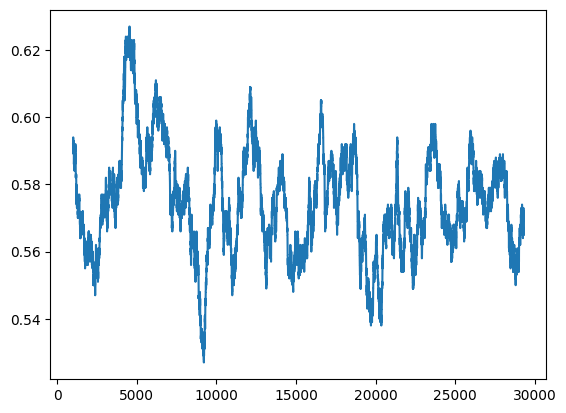

In [78]:
res_df['rolling'].plot()

In [79]:
res_df.to_csv("acm_dl_matched.csv", index=False)